# (노트) 역행렬이 존재하지 않는 선형회귀
> 작성중 
- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [응용통계]

### About this doc

`-` 2021년 1학기 전북대학교 데이터과학 강의노트

### Introduction 

`-` 질문: 언제 $\big(\bf X^\top X\big)^{-1}$가 존재하지 않는가? 

#### 수학과 학생의 답변

일반적인 정사각행렬 ${\bf A}$를 생각하자. 

${\bf A}$의 역행렬이 존재할 조건은 $\bf A$가 full-rank matrix일 경우이다. 

$\bf A$의 rank는 일차독립인 열 (혹은 행) 의 수이다. 

문제의 경우 관심있는 행렬 $\bf A$는 $\bf X^\top X$이다. 

$\bf X^\top X$는 $p \times p$ matrix이므로, $\bf X^\top X$의 rank가 $p$보다 작은 경우에 역행렬이 존재하지 않는다. 

즉 $rank\big({\bf X}^\top {\bf X} \big)< p$ 일때 역행렬이 존재하지 않음. 

#### 통계학과 학생의 답변

`-` **[경우1]** 너무 적은 자료 

$\bf X$의 차원이 $n\times p$일 때, $n<p$ 이면 $\bf X^\top X$의 역행렬이 존재하지 않는다. 즉 설명변수의 수가 관측치의 수보다 적으면 역행렬이 존재하지 않는다.

(왜?)

$\bf X$의 랭크는 아무리 커봐야 $n$이다. $\bf X^\top$의 랭크도 아무리 커봐야 $n$이다. 

따라서 $\bf X^\top X$의 랭크도 아무리 커봐야 $n$이다. (아래의 노트 참고) 

> Note: $rank({\bf A B})\leq \min\Big(rank({\bf A}), rank({\bf B})\Big)$ 

$n<p$ 이므로, $rank({\bf X^\top X})\leq n <p$

따라서 역행렬이 없다. 

`-` **[경우2]** 다중공선성

$n > p$ 이더라도, 다중공선성이 있는 경우에는 역행렬이 없다. 

다중공선성:

- 설명변수간의 일차독립성이 보장되지 않는 경우. 
- $p-1$개의 설명변수를 알고 있다면, 나머지 1개의 설명변수는 항상 $p-1$개의 설명변수의 선형조합으로 만들어 낼 수 있다 $\to$ 이 경우 $rank({\bf X'X})=p-1$
- 즉 불필요한 설명변수가 있음을 의미함. 

### 예제1: 연봉 ~ 토익+학점+텝스

`-` 직관: 사실상 토익점수만 있으면 텝스는 불필요한 변수 아닌가? 

`-` 데이터만들기

In [6]:
import rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [2]:
%%R 
n<-20
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
teps<-toeic - 10
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=300)
sal<-round(sal)

given: (`sal`,`toeic`,`gpa`,`teps`)

`-` 회귀분석을 해보자.

In [3]:
%%R 
lm(sal~gpa+toeic+teps)


Call:
lm(formula = sal ~ gpa + toeic + teps)

Coefficients:
(Intercept)          gpa        toeic         teps  
    321.301      629.597        4.476           NA  



-> `NA`발생

`-` 역행렬을 구해보자. 

In [4]:
%%R 
X<- cbind(1,gpa,toeic,teps)
solve(t(X)%*%X)

R[write to console]: Error in solve.default(t(X) %*% X) : 
  system is computationally singular: reciprocal condition number = 2.66121e-21




Error in solve.default(t(X) %*% X) : 
  system is computationally singular: reciprocal condition number = 2.66121e-21


-> 역행렬 구하기 실패

`-` `det`을 이용하여 디터미넌트를 구해보자. 

In [5]:
%%R 
det(t(X)%*%X)

[1] 4.274158e-05


-> 거의 0 이라고 봐야함. 

#### 왜 이런일이 일어나는가? 

토익점수와 텝스점수가 선형적으로 종속되어 있기 때문이다. (수학적설명)

우리는 이미 참모형에서 `토익점수-100=텝스점수`의 관계가 성립함을 알고 있다. 

다시말하면, 토익점수만 알면 텝스점수는 반드시 알아낼 수 있다. (다중공선성)

즉 토익점수 혹은 텝스점수중 하나는 `필요없는 설명변수`이다. 

### 역행렬이 없을 경우 문제해결법

`-` 문제:  $\bf X^\top X$의 역형렬을 구할 수 없어서 모델을 학습하지 못하는 문제를 어떻게 해결할 것인가? 

`-` 아이디어: 역행렬을 구할순 없지만, 역행렬 비슷한것을 구해서 해결한다. 

`-` 이러한 접근에는 크게 2가지 계열이 있다고 볼 수 있다. 

### 역행렬 비슷한것을 구하는 방법1

#### 1차원

`-` 역행렬을 구하지 못하는 것은 1차원으로 바꿔서 생각하면 역수를 구하지 못하는 것과 비슷하다. 

예를들면 $\frac{3}{x}$와 같은 꼴에서 $x=0$ 인 경우를 계산하지 못해 코드에서 에러가 발생하는 것이다. 

이러한 에러를 회피하려면 분모에 $0$에 가까운 **양수** $\lambda$를 더하면 된다. 

즉 $\frac{3}{x}$ 의 꼴이 $\frac{3}{x+\lambda}$로 변화하는 셈이 된다. 

$\frac{3}{x}$대신에 $\frac{3}{x+\lambda}$를 사용하면 2개의 장점이 있다. 

(장점1) $x=0$ 일때 에러가 나지 않음. 

(장점2) $x\neq 0$ 일때 $\frac{3}{x}$ 와 거의 비슷한 값을 준다는 것이다. 

즉 $\frac{3}{x+\lambda}$는 $\frac{3}{x}$와 거의 비슷하면서도 $x=0$ 일때 생기는 에러를 회피할 수 있다. 

`-` **$\lambda$는 왜 양수이어야 하는가?**

위에서 살짝 언급을 피한 부분이 있는데 바로 $\frac{3}{x+\lambda}$에서 $x+\lambda$가 다시 0이 되면 어떡하냐는 것이다. 

하지만 사실 이럴 일은 없는것이 우리는 사실 $x$가 항상 양의 값을 가지는 경우만 따지면 되기 때문이다. 

$\lambda>0$ 

#### $p$차원

`-` 이러한 아이디어를 다차원으로 확장하자. 

전략: 앞으로는 ${\bf X^\top X}$의 역행렬을 구할 것이 아니라 $\big({\bf X^\top X}+\lambda \bf I\big)$의 역행렬을 구하도록 하자. 단, $\lambda >0$. 
- 이때 ${\bf X^\top X}$ 반양정치행렬(semi positive definite matrix)이 된다. 
- 이것이 실수로치면 $\geq 0$의 조건이라고 생각하면 된다. 

### 역행렬 비슷한 것을 구하는 방법2

#### 선형대수학복습

(예비학습) ${\bf X}^\top{\bf X}$의 고유값분해를 이용하여 ${\bf X}^\top{\bf X}$의 역행렬을 계산하는 방법

${\bf X}^\top{\bf X}$는 모든 원소가 실수이고 대칭행렬이므로 고유값분해를 할 수 있다. (??) 

- note: ${\bf A}$가 대칭행렬이다. $\Leftrightarrow$ $\bf A^\top = A$. 

쉽게 말하면 아래를 만족하는 직교행렬 $\boldsymbol{\Psi}$와 대각행렬 $\boldsymbol{\Lambda}$를 항상 찾을 수 있다는 이야기이다. 

$\bf X^\top \bf X=\boldsymbol{\Psi}\boldsymbol{\Lambda}\boldsymbol{\Psi}^\top $

- note: $\boldsymbol{\Psi}$가 직교행렬이다. $\Leftrightarrow$ $\boldsymbol{\Psi}^\top \boldsymbol{\Psi}=\boldsymbol{\Psi}\boldsymbol{\Psi}^\top=\bf I$
- note: $\boldsymbol{\Psi}$는 당연히 정사각행렬이어야함. (왜냐하면 정사각행렬이 아니면 첫번째 등호가 성립안하겠죠?)

주장: ${\bf X}^\top{\bf X}$의 역행렬은 $\boldsymbol{\Psi}\boldsymbol{\Lambda}^{-1}\boldsymbol{\Psi}^\top$이다. 

증명: 너무쉬움.. 그냥 곱하면 됨..

직관: $\boldsymbol{\Lambda}^{-1}$만 존재하면 $\big({\bf X}^\top {\bf X} \big)^{-1}$이 존재하는 것이 아닌가? 

(아이디어) $\boldsymbol{\Lambda}^{-1}$만 존재하지 않는다는 것은 대각선에 $0$인 원소가 끼어있다는 이야기임. 

$\boldsymbol{\Lambda}^{-1}$는 결국 $\boldsymbol{\Lambda}$의 모든 대각선원소를 역수취하면 얻을 수 있는데, $0$이 있어서 역수를 못취하는 것임. 

$0$인 원소는 빼고 역수를 취하면 되지 않을까? 

In [10]:
λ, Ψ = np.linalg.eig(X.T*X)

In [11]:
Λ=np.matrix(np.diag(λ))

In [12]:
X.T*X

matrix([[2.0000000e+01, 7.0400000e+01, 1.4266000e+04, 1.4066000e+04],
        [7.0400000e+01, 2.5000000e+02, 5.0035000e+04, 4.9331000e+04],
        [1.4266000e+04, 5.0035000e+04, 1.0283246e+07, 1.0140586e+07],
        [1.4066000e+04, 4.9331000e+04, 1.0140586e+07, 9.9999260e+06]])

In [13]:
Ψ*Λ*Ψ.T

matrix([[2.0000000e+01, 7.0400000e+01, 1.4266000e+04, 1.4066000e+04],
        [7.0400000e+01, 2.5000000e+02, 5.0035000e+04, 4.9331000e+04],
        [1.4266000e+04, 5.0035000e+04, 1.0283246e+07, 1.0140586e+07],
        [1.4066000e+04, 4.9331000e+04, 1.0140586e+07, 9.9999260e+06]])

In [14]:
Λ

matrix([[2.02834246e+07, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.61241468e+01, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.37339356e-13, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.26211677e+00]])

In [15]:
Λ[0,0], Λ[1,1], Λ[2,2], Λ[3,3]

(20283424.613736466,
 16.124146751413505,
 3.3733935585117786e-13,
 1.2621167718825437)

In [16]:
Λ_invlike=[[1/Λ[0,0],0,0,0],
       [0,1/Λ[1,1],0,0],
       [0,0,0,0],
       [0,0,0,1/Λ[3,3]]]

In [17]:
Λ_invlike=np.matrix(Λ_invlike)
Λ_invlike

matrix([[4.93013393e-08, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 6.20187856e-02, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.92319714e-01]])

In [18]:
Ψ*Λ_invlike*Ψ.T ## X'X 의 역행렬 비슷한것.. 

matrix([[ 0.00635302, -0.04904841,  0.03165894, -0.03187125],
        [-0.04904841,  0.53032917, -0.24479401,  0.24569011],
        [ 0.03165894, -0.24479401,  0.15776667, -0.15882276],
        [-0.03187125,  0.24569011, -0.15882276,  0.15988969]])

In [19]:
np.round((X.T*X)* (Ψ*Λ_invlike*Ψ.T),3)

array([[ 0.02 ,  0.   ,  0.098, -0.098],
       [ 0.   ,  1.   ,  0.   , -0.   ],
       [ 0.098,  0.   ,  0.99 ,  0.01 ],
       [-0.098, -0.   ,  0.01 ,  0.99 ]])

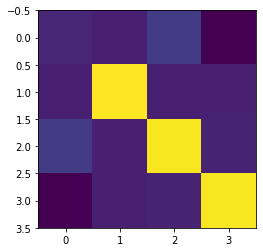

In [20]:
import matplotlib.pyplot as plt 
plt.imshow((X.T*X)* (Ψ*Λ_invlike*Ψ.T))

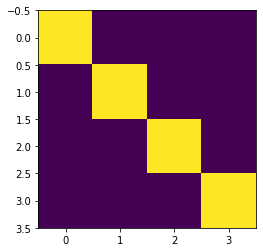

In [21]:
plt.imshow([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]])

### 요약 ($\star\star\star$)

(1) 종종 $\bf X^\top X$의 역행렬을 구하기 어려울 경우가 있다. 

(2) 이는 다중공선성 문제와 연결된다.  

(3) $\bf X^\top X$의 역행렬이 없을때, 역행렬 비슷한 것을 구하기 위한 고민은 공학적 접근과 수학적 접근으로 나눌 수 있다. 

(4) 이중 공학적인 접근은 능형회귀(Ridge regression)로 수학적인 접근은 주성분분석(PCA)로 해석할 수 있다. 

### Appendix A. 

(주장) ${\bf X^\top X}= \boldsymbol{\Psi} \boldsymbol{\Lambda} \boldsymbol{\Psi}^\top= \sum_{j=1}^{p}\lambda_j\psi_j\psi_j^\top$ (단, $\boldsymbol{\Psi}=[\psi_1 \psi_2 \dots \psi_p]$)

(확인)

`-` 고유벡터의 정의

In [22]:
np.round(Ψ,3)

array([[ 0.001, -0.112, -0.99 ,  0.084],
       [ 0.003, -0.599,  0.   , -0.801],
       [ 0.712, -0.555,  0.099,  0.418],
       [ 0.702,  0.566, -0.099, -0.42 ]])

In [23]:
ψ1=Ψ[:,0]
ψ2=Ψ[:,1]
ψ3=Ψ[:,2]
ψ4=Ψ[:,3]

In [24]:
ψ1

matrix([[0.00098772],
        [0.00346414],
        [0.71202356],
        [0.70214634]])

In [25]:
ψ4

matrix([[ 0.08386966],
        [-0.80078571],
        [ 0.41832242],
        [-0.42037422]])

`-` 고유값을 정의

In [26]:
λ1=Λ[0,0]
λ2=Λ[1,1]
λ3=Λ[2,2]
λ4=Λ[3,3]

In [27]:
λ1,λ2,λ3,λ4

(20283424.613736466,
 16.124146751413505,
 3.3733935585117786e-13,
 1.2621167718825437)

$ \sum_{j=1}^{4}\lambda_j\psi_j\psi_j^\top$

In [28]:
λ1*ψ1*ψ1.T + λ2*ψ2*ψ2.T + λ3*ψ3*ψ3.T + λ4*ψ4*ψ4.T

matrix([[2.0000000e+01, 7.0400000e+01, 1.4266000e+04, 1.4066000e+04],
        [7.0400000e+01, 2.5000000e+02, 5.0035000e+04, 4.9331000e+04],
        [1.4266000e+04, 5.0035000e+04, 1.0283246e+07, 1.0140586e+07],
        [1.4066000e+04, 4.9331000e+04, 1.0140586e+07, 9.9999260e+06]])

In [29]:
X.T*X

matrix([[2.0000000e+01, 7.0400000e+01, 1.4266000e+04, 1.4066000e+04],
        [7.0400000e+01, 2.5000000e+02, 5.0035000e+04, 4.9331000e+04],
        [1.4266000e+04, 5.0035000e+04, 1.0283246e+07, 1.0140586e+07],
        [1.4066000e+04, 4.9331000e+04, 1.0140586e+07, 9.9999260e+06]])

그런데.. 

$\lambda_3 \approx 0$ 이므로, 

$\lambda_3\psi_3\psi_3^\top$를 빼도 거의 $\bf X^\top X$와 비슷할것이다. 

(확인)

In [30]:
λ1*ψ1*ψ1.T+λ2*ψ2*ψ2.T+λ4*ψ4*ψ4.T

matrix([[2.0000000e+01, 7.0400000e+01, 1.4266000e+04, 1.4066000e+04],
        [7.0400000e+01, 2.5000000e+02, 5.0035000e+04, 4.9331000e+04],
        [1.4266000e+04, 5.0035000e+04, 1.0283246e+07, 1.0140586e+07],
        [1.4066000e+04, 4.9331000e+04, 1.0140586e+07, 9.9999260e+06]])

In [31]:
λ1*ψ1*ψ1.T+λ2*ψ2*ψ2.T

matrix([[1.99911221e+01, 7.04847658e+01, 1.42659557e+04, 1.40660445e+04],
        [7.04847658e+01, 2.49190658e+02, 5.00354228e+04, 4.93305751e+04],
        [1.42659557e+04, 5.00354228e+04, 1.02832458e+07, 1.01405862e+07],
        [1.40660445e+04, 4.93305751e+04, 1.01405862e+07, 9.99992578e+06]])

In [32]:
X.T*X

matrix([[2.0000000e+01, 7.0400000e+01, 1.4266000e+04, 1.4066000e+04],
        [7.0400000e+01, 2.5000000e+02, 5.0035000e+04, 4.9331000e+04],
        [1.4266000e+04, 5.0035000e+04, 1.0283246e+07, 1.0140586e+07],
        [1.4066000e+04, 4.9331000e+04, 1.0140586e+07, 9.9999260e+06]])

즉 $\lambda_1\psi_1\psi_1^\top+\lambda_2\psi_2\psi_2^\top \approx {\bf X}^\top{\bf X}$

PCA를 통한 차원축소의 아이디어로 연결!

### Appendix B. 

SVD(singular value decomposition)라는 것이 있다. 

$\bf X=UDV^\top$ 

- ${\bf X}: n\times p$ 행렬 
- ${\bf U}: n\times n$ 직교행렬 or $n \times p$ 직교행렬 비슷한 행렬 
- ${\bf D}: n\times p$ 대각행렬 비슷한 행렬 or $p\times p$ 대각행렬 
- ${\bf V}: p\times p$ 직교행렬 

즉 임의의 매트릭스 $\bf X$를 분해할 수 있다는 것이다. 

(실습)

In [33]:
U,d,Vt = np.linalg.svd(X)

In [34]:
X.shape

(20, 4)

In [35]:
U.shape,d.shape,Vt.shape

((20, 20), (4,), (4, 4))

In [36]:
%%R 
svdrslt<-svd(X)
D<-diag(svdrslt$d)
U<-svdrslt$u
V<-svdrslt$v
print(dim(U))
print(dim(D))
print(dim(V))

[1] 20  4
[1] 4 4
[1] 4 4


In [38]:
%%R 
U%*%D%*%t(V)

      [,1] [,2] [,3] [,4]
 [1,]    1  3.7  811  801
 [2,]    1  3.8  716  706
 [3,]    1  3.9  701  691
 [4,]    1  3.3  767  757
 [5,]    1  3.8  543  533
 [6,]    1  3.2  666  656
 [7,]    1  3.3  740  730
 [8,]    1  3.5  690  680
 [9,]    1  3.0  716  706
[10,]    1  3.2  706  696
[11,]    1  3.7  733  723
[12,]    1  3.6  677  667
[13,]    1  3.1  681  671
[14,]    1  4.3  627  617
[15,]    1  3.6  814  804
[16,]    1  3.1  769  759
[17,]    1  4.0  614  604
[18,]    1  3.5  796  786
[19,]    1  3.5  651  641
[20,]    1  3.3  848  838


In [39]:
%%R 
X

        gpa toeic teps
 [1,] 1 3.7   811  801
 [2,] 1 3.8   716  706
 [3,] 1 3.9   701  691
 [4,] 1 3.3   767  757
 [5,] 1 3.8   543  533
 [6,] 1 3.2   666  656
 [7,] 1 3.3   740  730
 [8,] 1 3.5   690  680
 [9,] 1 3.0   716  706
[10,] 1 3.2   706  696
[11,] 1 3.7   733  723
[12,] 1 3.6   677  667
[13,] 1 3.1   681  671
[14,] 1 4.3   627  617
[15,] 1 3.6   814  804
[16,] 1 3.1   769  759
[17,] 1 4.0   614  604
[18,] 1 3.5   796  786
[19,] 1 3.5   651  641
[20,] 1 3.3   848  838


고유분해와 어떤관계가 있을까? 

우리가 관심있는 매트릭스는 $\bf X^\top X$로 한정하자. 

(분해관점1)

고유값분해: $\bf X^\top X$는 대칭행렬이므로 고유값분해가 존재함. 

따라서 ${\bf X^\top X}=\boldsymbol{\Psi}\boldsymbol{\Lambda}\boldsymbol{\Psi}^\top$. 

(분해관점2)

SVD: 임의의 매트릭스 ${\bf X}$를 아래와 같이 분해할 수 있다. 

$\bf X=UDV^\top$ 

따라서 $\bf X^\top X$는 아래와 같이 쓸 수 있다.

$\bf X^\top X =(UDV^\top)^\top(UDV^\top)$

$=\bf VD^\top U^\top UDV^\top$

$= \bf VD^\top D V^\top$ 

결국 우리가 관심있는 매트릭스 $\bf X^\top X$와 같은 꼴에 한정하면 아래와 같이 생각할수 있다. 

(1) $\boldsymbol{\Psi}=\bf V$

(2) $\boldsymbol{\Lambda}=\bf D^\top D$

(확인)

In [40]:
Ψ

matrix([[ 9.87721869e-04, -1.12128261e-01, -9.90147543e-01,
          8.38696640e-02],
        [ 3.46413964e-03, -5.98940943e-01,  1.13530343e-12,
         -8.00785706e-01],
        [ 7.12023556e-01, -5.55180051e-01,  9.90147543e-02,
          4.18322417e-01],
        [ 7.02146338e-01,  5.66102562e-01, -9.90147543e-02,
         -4.20374224e-01]])

In [41]:
%%R 
V

              [,1]       [,2]        [,3]          [,4]
[1,] -0.0009877219  0.1121283  0.08386966  9.901475e-01
[2,] -0.0034641396  0.5989409 -0.80078571 -4.346004e-15
[3,] -0.7120235563  0.5551801  0.41832242 -9.901475e-02
[4,] -0.7021463376 -0.5661026 -0.42037422  9.901475e-02


In [42]:
Λ

matrix([[2.02834246e+07, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.61241468e+01, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.37339356e-13, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.26211677e+00]])

In [43]:
%%R 
t(D)%*%D

         [,1]     [,2]     [,3]         [,4]
[1,] 20283425  0.00000 0.000000 0.000000e+00
[2,]        0 16.12415 0.000000 0.000000e+00
[3,]        0  0.00000 1.262117 0.000000e+00
[4,]        0  0.00000 0.000000 1.817603e-27


(raw rank approximation)

${\bf X^\top X}= \boldsymbol{\Psi} \boldsymbol{\Lambda} \boldsymbol{\Psi}^\top= \sum_{j=1}^{p}\lambda_j\psi_j\psi_j^\top$ 와 비슷한 방법으로 

${\bf X^\top X}= \boldsymbol{\Psi} \boldsymbol{\Lambda} \boldsymbol{\Psi}^\top= {\bf V D^\top D V^\top}=\sum_{j=1}^{p}d_j^2v_jv_j^\top$

의 관점으로 $\bf X$를 근사시킬 수 있음. 

In [44]:
%%R 
D

         [,1]     [,2]    [,3]         [,4]
[1,] 4503.712 0.000000 0.00000 0.000000e+00
[2,]    0.000 4.015488 0.00000 0.000000e+00
[3,]    0.000 0.000000 1.12344 0.000000e+00
[4,]    0.000 0.000000 0.00000 4.263335e-14


In [45]:
%%R
d1<-D[1,1]
d2<-D[2,2]

In [46]:
%%R 
v1<-V[,1]
v2<-V[,2]

In [47]:
%%R 
d1^2 * v1%*%t(v1)+ d2^2 * v2%*%t(v2) 

            [,1]        [,2]        [,3]        [,4]
[1,]    19.99112    70.48477    14265.96    14066.04
[2,]    70.48477   249.19066    50035.42    49330.58
[3,] 14265.95572 50035.42279 10283245.78 10140586.22
[4,] 14066.04450 49330.57513 10140586.22  9999925.78


In [48]:
λ1*ψ1*ψ1.T+λ2*ψ2*ψ2.T

matrix([[1.99911221e+01, 7.04847658e+01, 1.42659557e+04, 1.40660445e+04],
        [7.04847658e+01, 2.49190658e+02, 5.00354228e+04, 4.93305751e+04],
        [1.42659557e+04, 5.00354228e+04, 1.02832458e+07, 1.01405862e+07],
        [1.40660445e+04, 4.93305751e+04, 1.01405862e+07, 9.99992578e+06]])

In [49]:
X.T*X

matrix([[2.0000000e+01, 7.0400000e+01, 1.4266000e+04, 1.4066000e+04],
        [7.0400000e+01, 2.5000000e+02, 5.0035000e+04, 4.9331000e+04],
        [1.4266000e+04, 5.0035000e+04, 1.0283246e+07, 1.0140586e+07],
        [1.4066000e+04, 4.9331000e+04, 1.0140586e+07, 9.9999260e+06]])